In [17]:
from flowstab.flow_stability import FlowStability
from flowstab.network_clustering import Clustering,avg_norm_var_information, run_multi_louvain
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
from sankeyflow import Sankey
import matplotlib.colors as mcolors
import os
import json
#from concurrent.futures import ProcessPoolExecutor
#from functools import partial
datadir = 'mice_data'
net_file = os.path.join(datadir,'micenet_2017_02_28_to_2017_05_01')

In [1]:
! pip uninstall -y tempnet


Found existing installation: tempnet 1.0.0rc3.dev81+g26fbe2f64.d20260624
Uninstalling tempnet-1.0.0rc3.dev81+g26fbe2f64.d20260624:
  Successfully uninstalled tempnet-1.0.0rc3.dev81+g26fbe2f64.d20260624


In [2]:
! pip uninstall -y flow stab
!pip install -e C:/Users/Yasaman/flow_stability/

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///C:/Users/Yasaman/flow_stability
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/bovet-research-group/stochmat.git to c:\users\yasaman\appdata\local\temp\pip-install-pfkrtbg4\stochmat_228b00acc7a949928459373103ccb032
  Resolved https://github.com/bovet-research-group/stochmat.git to commit 92e20e525d5396bd3168eebb1899fd7

  Running command git clone --filter=blob:none --quiet https://github.com/bovet-research-group/stochmat.git 'C:\Users\Yasaman\AppData\Local\Temp\pip-install-pfkrtbg4\stochmat_228b00acc7a949928459373103ccb032'
  Running command git clone --filter=blob:none --quiet https://github.com/bovet-research-group/temporal-networks.git 'C:\Users\Yasaman\AppData\Local\Temp\pip-install-pfkrtbg4\tempnet_a112639d6eb548ee92e5ebe18b262f26'
  Running command git checkout -b integration --track origin/integration
  branch 'integration' set up to track 'origin/integration'.
  Switched to a new branch 'integration'

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

!pip install --force-reinstall --no-deps "tempnet @ git+https://github.com/bovet-research-group/temporal-networks.git@integration"

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/bovet-research-group/temporal-networks.git (to revision integration) to c:\users\yasaman\appdata\local\temp\pip-install-d99xushd\tempnet_a8c308c3bef644c0914106dbd5d41b4c
  Resolved https://github.com/bovet-research-group/temporal-networks.git to commit 8c5056a5445c413817d03226bf274273cd566841
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for tempnet: filename=tempnet-1.0.0rc3.dev117+g8c5056a54-py3-none-any.whl size=40818 sha256=80635c890f5e3083fe8e7dee796823e59ee0de7f3fe421188ce5e08a90842db5
  Stored in directory: C:\Users\Yasaman\AppData\Local\Temp\pip-ephem-wheel-cache-bk1to6_x\wheels

  Running command git clone --filter=blob:none --quiet https://github.com/bovet-research-group/temporal-networks.git 'C:\Users\Yasaman\AppData\Local\Temp\pip-install-d99xushd\tempnet_a8c308c3bef644c0914106dbd5d41b4c'
  Running command git checkout -b integration --track origin/integration
  branch 'integration' set up to track 'origin/integration'.
  Switched to a new branch 'integration'

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# dont forget to install this now.
! pip install sankeyflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
#  helpers 
def _convert_sets_to_community_id(partitions_set, N):
    """Convert a list of partitions in set format to a list of community id arrays."""
    partitions_id = []
    for partition in partitions_set:
        partition_id = np.zeros(N, dtype=int)
        for cluster_id, cluster in enumerate(partition):
            for node in cluster:
                partition_id[node] = cluster_id
        partitions_id.append(partition_id)
    return partitions_id


def _process_direction(clus_obj, n_nodes, num_repeat=10):
    _, cluster_lists, stabilities, _ = run_multi_louvain(
        Clustering(p1=clus_obj.p1, p2=None, S=clus_obj.I_list[0]),
        num_repeat=num_repeat,
    )
    best_id = np.argmax(stabilities)
    partitions_id = _convert_sets_to_community_id(cluster_lists, n_nodes)
    return {
        "community_id_best": partitions_id[best_id],
        "stability_best": stabilities[best_id],
        "number_of_communities_best": len(np.unique(partitions_id[best_id])),
        "NVI": avg_norm_var_information(cluster_lists),
    }


def _process_tau(clus_f, clus_b, n_nodes, num_repeat=10):
    return (_process_direction(clus_f, n_nodes, num_repeat),
            _process_direction(clus_b, n_nodes, num_repeat))



def plot_forward_backward_sankey(f_results, b_results, scale,
                                 min_flow=1, figsize=(10, 8),
                                 title=None):
    tau = 1 / scale

    f_labels = np.asarray(np.ravel(f_results[tau]["community_id_best"]))
    b_labels = np.asarray(np.ravel(b_results[tau]["community_id_best"]))

    f_comms = np.unique(f_labels)
    b_comms = np.unique(b_labels)

    overlap = np.zeros((len(f_comms), len(b_comms)), dtype=int)
    f_index = {c: i for i, c in enumerate(f_comms)}
    b_index = {c: i for i, c in enumerate(b_comms)}
    for fl, bl in zip(f_labels, b_labels):
        overlap[f_index[fl], b_index[bl]] += 1

    f_names = [f"F{c}" for c in f_comms]
    b_names = [f"B{c}" for c in b_comms]

    nodes = [
        [(name, int(overlap[i].sum())) for i, name in enumerate(f_names)],
        [(name, int(overlap[:, j].sum())) for j, name in enumerate(b_names)],
    ]

    flows = []
    for i, fn in enumerate(f_names):
        for j, bn in enumerate(b_names):
            v = int(overlap[i, j])
            if v >= min_flow:
                flows.append((fn, bn, v))
  
    color='teal'
    fig = plt.figure(figsize=figsize)
    s = Sankey(
        flows=flows,
        nodes=nodes,
        node_opts=dict(label_format='{label}', color=color),
        flow_color_mode='source',         
    )
    flow_rgba = (*mcolors.to_rgb(color), 0.1)
    for flow in s.flows:
        flow.color = flow_rgba
    s.draw()
    plt.title(title or f"Forward → Backward overlap (scale={scale:g}, τ={tau:g})")
    plt.tight_layout()



def plot_flow_stability(f_results, b_results, scales):
    taus = 1 / scales

    def extract(results, key):
        return np.array([np.ravel(results[t][key])[0] for t in taus])

    f_stab = extract(f_results, "stability_best")
    b_stab = extract(b_results, "stability_best")
    f_nclu = extract(f_results, "number_of_communities_best")
    b_nclu = extract(b_results, "number_of_communities_best")
    f_nvi  = extract(f_results, "NVI")
    b_nvi  = extract(b_results, "NVI")

    c_blue, c_red, c_green = "#1f77b4", "#d62728", "#52a452"

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(8, 5), sharex=True
    )

    ax_top.plot(scales, f_stab, color=c_blue, lw=2, ls="-",  label="forward")
    ax_top.plot(scales, b_stab, color=c_blue, lw=2, ls="--", label="backward")
    ax_top.set_ylabel("Stability", color=c_blue)
    ax_top.tick_params(axis="y", labelcolor=c_blue)
    ax_top.set_ylim(0, 1.05)
    ax_top.legend(loc="lower left", fontsize=8, frameon=False)

    ax_top2 = ax_top.twinx()
    ax_top2.plot(scales, f_nclu, color=c_red, lw=2, ls="-")
    ax_top2.plot(scales, b_nclu, color=c_red, lw=2, ls="--")
    ax_top2.set_ylabel("# clusters", color=c_red)
    ax_top2.tick_params(axis="y", labelcolor=c_red)

    ax_top.set_title("Flow Stability")

    ax_bot.plot(scales, f_nvi, color=c_green, lw=2, ls="-",  label="forward")
    ax_bot.plot(scales, b_nvi, color=c_green, lw=2, ls="--", label="backward")
    ax_bot.set_ylabel("NVI", color=c_green)
    ax_bot.tick_params(axis="y", labelcolor=c_green)
    ax_bot.legend(loc="upper right", fontsize=8, frameon=False)

    ax_bot.set_xlabel(r"$\tau$")
    ax_bot.set_xscale("log")

    plt.tight_layout()
    return fig


In [20]:
os.makedirs(datadir, exist_ok=True)
!wget https://zenodo.org/record/4725155/files/mice_contact_sequence.csv.gz -P mice_data/

--2026-06-23 22:32:38--  https://zenodo.org/record/4725155/files/mice_contact_sequence.csv.gz
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4725155/files/mice_contact_sequence.csv.gz [following]
--2026-06-23 22:32:38--  https://zenodo.org/records/4725155/files/mice_contact_sequence.csv.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 53670209 (51M) [text/plain]
Saving to: 'mice_data/mice_contact_sequence.csv.gz.1'

     0K .......... .......... .......... .......... ..........  0%  655K 80s
    50K .......... .......... .......... .......... ..........  0% 1.34M 59s
   100K .......... .......... .......... .......... ..........  0% 1.94M 48s
   150K .......... .......... .......... .......... ..........  0% 1.62M 44s
   200K .......... ..

In [21]:
!wget https://zenodo.org/record/4725155/files/mice_sex.json -P mice_data/

--2026-06-23 22:32:46--  https://zenodo.org/record/4725155/files/mice_sex.json
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4725155/files/mice_sex.json [following]
--2026-06-23 22:32:47--  https://zenodo.org/records/4725155/files/mice_sex.json
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2110 (2.1K) [text/plain]
Saving to: 'mice_data/mice_sex.json.1'

     0K ..                                                    100%  178K=0.01s

2026-06-23 22:32:47 (178 KB/s) - 'mice_data/mice_sex.json.1' saved [2110/2110]



In [22]:
contact_sequence = pd.read_csv(os.path.join(datadir,'mice_contact_sequence.csv.gz'),compression='gzip')

with open(os.path.join(datadir,'mice_sex.json'),'r') as fopen:
    sex_dict = json.load(fopen)    

In [23]:
events_table = contact_sequence[contact_sequence['ending_times'] <= 1800] 

In [24]:
#Step 1: set up the flow stability instance with the tempnet object inside
fs = FlowStability()
fs.set_temporal_network(events_table=events_table, relabel_nodes=True)

n_nodes=fs.temporal_network.num_nodes

#Step 2 start computing the laplacians
fs.compute_laplacian_matrices()

2026-06-23 22:33:01,905 - INFO - flowstab\flow_stability.py:234- PID:13352 - Set an empty temporal network.
2026-06-23 22:33:01,907 - INFO - flowstab\flow_stability.py:138- PID:13352 - Successfully initiated a FlowStability instance!
2026-06-23 22:33:01,909 - INFO - flowstab\flow_stability.py:229- PID:13352 - Set the temporal network: <class 'tempnet.temporal_network.ContTempNetwork'> with 167 nodes and 1400 events
2026-06-23 22:33:01,921 - INFO - tempnet\temporal_network.py:1278- PID:13352 - Computing Laplacians
2026-06-23 22:33:01,946 - INFO - tempnet\temporal_network.py:1337- PID:13352 - 0 over 843
2026-06-23 22:33:01,946 - INFO - tempnet\temporal_network.py:1341- PID:13352 - 0.00s
2026-06-23 22:33:09,002 - INFO - tempnet\temporal_network.py:1388- PID:13352 - Finished in 7.060180187225342


<class 'flowstab.flow_stability.FlowStability'>
- temporal network: <class 'tempnet.temporal_network.ContTempNetwork'> with 167 nodes and 1400 events
- t_start: None
- t_stop: None
- time_scale: <list_iterator object at 0x0000019330CA20E0>

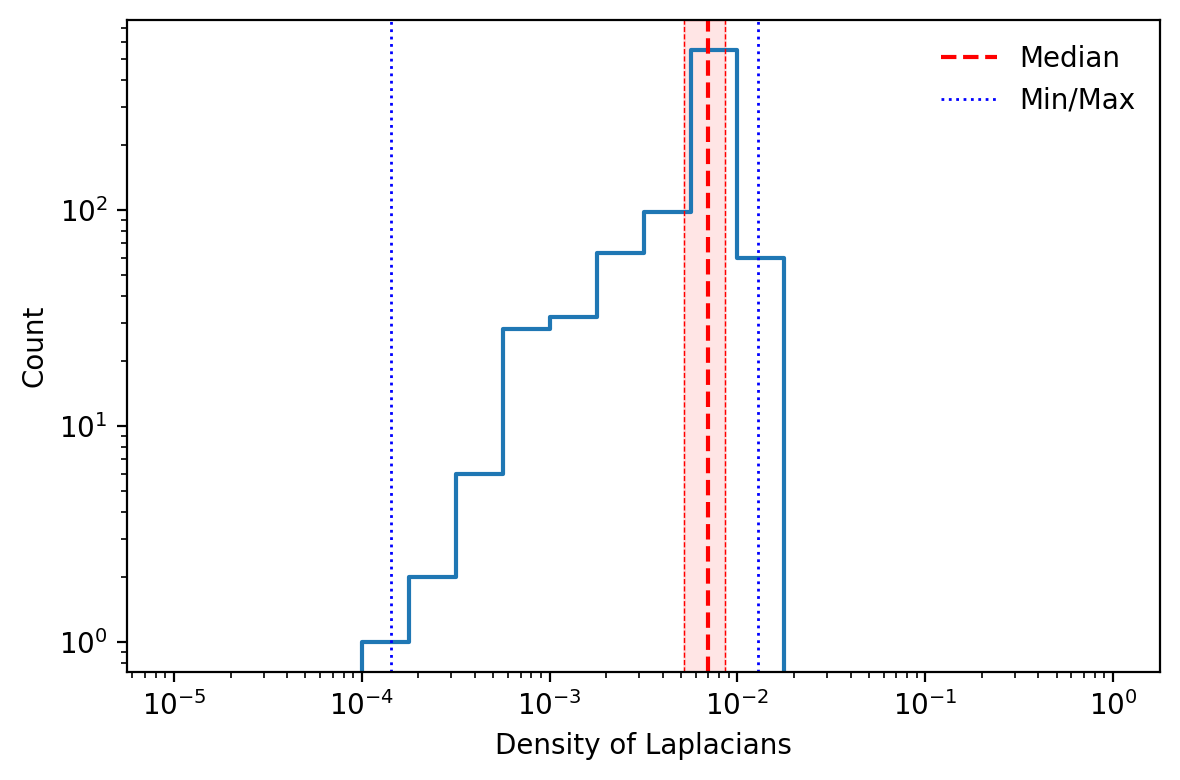

C:\Users\Yasaman\AppData\Roaming\Python\Python312\site-packages\tempnet\expm_with_tol.py:259: RuntimeWarning: overflow encountered in scalar power
  rj = 2 * rj + rj**2



=== dense_expm ===
  L_min     avg=1.5036s  min_scale=0.8503s  max_scale=3.4269s
  L_q25     avg=1.4282s  min_scale=0.7654s  max_scale=3.3659s
  L_median  avg=1.3027s  min_scale=1.0581s  max_scale=2.3356s
  L_q75     avg=0.3205s  min_scale=0.0244s  max_scale=0.9669s
  L_max     avg=0.8875s  min_scale=0.0405s  max_scale=3.4490s
  total: 54.4240s

=== sparse_expm ===
  L_min     avg=0.0456s  min_scale=0.0244s  max_scale=0.0781s
  L_q25     avg=0.0678s  min_scale=0.0617s  max_scale=0.0940s
  L_median  avg=0.0468s  min_scale=0.0273s  max_scale=0.0636s
  L_q75     avg=0.0675s  min_scale=0.0271s  max_scale=0.1086s
  L_max     avg=0.0830s  min_scale=0.0319s  max_scale=0.1376s
  total: 3.1063s

=== mfp_exp ===
  L_min     avg=0.0140s  min_scale=0.0016s  max_scale=0.0572s
  L_q25     avg=0.0104s  min_scale=0.0025s  max_scale=0.0236s
  L_median  avg=0.0247s  min_scale=0.0035s  max_scale=0.0852s
  L_q75     avg=0.0276s  min_scale=0.0035s  max_scale=0.0928s
  L_max     avg=0.0332s  min_scale=0.00

In [ ]:
##Step 2 : set scales
indices=fs.temporal_network.plot_density_of_laplacians()

min_scale = -7
max_scale = 2
n_scale = 10
scales = np.logspace(min_scale, max_scale, n_scale)
taus = 1 / scales

fs.temporal_network.print_report(indices,scales,force_csr=True, tol=1e-8)

In [26]:
# step 2: compute inter tranition matrices
fs.set_time_scale(taus)
fs.compute_inter_transition_matrices()

2026-06-23 22:34:08,926 - INFO - flowstab\flow_stability.py:529- PID:13352 - Computing inter T matrices for time_scale=10000000.0.
2026-06-23 22:36:09,842 - INFO - flowstab\flow_stability.py:540- PID:13352 - -> done.
2026-06-23 22:36:09,842 - INFO - flowstab\flow_stability.py:529- PID:13352 - Computing inter T matrices for time_scale=1000000.0.
2026-06-23 22:37:49,224 - INFO - flowstab\flow_stability.py:540- PID:13352 - -> done.
2026-06-23 22:37:49,224 - INFO - flowstab\flow_stability.py:529- PID:13352 - Computing inter T matrices for time_scale=99999.99999999999.
2026-06-23 22:39:26,451 - INFO - flowstab\flow_stability.py:540- PID:13352 - -> done.
2026-06-23 22:39:26,467 - INFO - flowstab\flow_stability.py:529- PID:13352 - Computing inter T matrices for time_scale=10000.0.
2026-06-23 22:41:02,784 - INFO - flowstab\flow_stability.py:540- PID:13352 - -> done.
2026-06-23 22:41:02,800 - INFO - flowstab\flow_stability.py:529- PID:13352 - Computing inter T matrices for time_scale=1000.0.
20

KeyboardInterrupt: 

In [ ]:
# step 3: create flow integrals
fs.time_direction = 0
fs.set_flow_clustering()
fs._temporal_network.inter_T = None
gc.collect()

2026-06-23 08:45:32,670 - INFO - flowstab\flow_stability.py:639- PID:13352 - Creating a flow integral clustering for time_scale=10000000.0.
2026-06-23 08:45:32,809 - INFO - flowstab\flow_stability.py:653- PID:13352 - 	- Creating the time backward clustering.
2026-06-23 08:45:35,785 - INFO - flowstab\flow_stability.py:667- PID:13352 - 	- Creating the time forward clustering.
2026-06-23 08:45:38,136 - INFO - flowstab\flow_stability.py:680- PID:13352 - -> done.
2026-06-23 08:45:38,147 - INFO - flowstab\flow_stability.py:639- PID:13352 - Creating a flow integral clustering for time_scale=1000000.0.
2026-06-23 08:45:38,284 - INFO - flowstab\flow_stability.py:653- PID:13352 - 	- Creating the time backward clustering.
2026-06-23 08:45:41,241 - INFO - flowstab\flow_stability.py:667- PID:13352 - 	- Creating the time forward clustering.
2026-06-23 08:45:43,587 - INFO - flowstab\flow_stability.py:680- PID:13352 - -> done.
2026-06-23 08:45:43,587 - INFO - flowstab\flow_stability.py:639- PID:13352 

18281

In [ ]:
# this is parallelizable--> But I don't know why it crashed when I do, probably some issues.
f_results, b_results = {}, {}
for tau in tqdm(taus):
    f_results[tau], b_results[tau] = _process_tau(fs.flow_clustering_forward[tau],
                        fs.flow_clustering_backward[tau], n_nodes,num_repeat=20)
    
    fs.flow_clustering_forward[tau]=None
    fs.flow_clustering_backward[tau]=None
    gc.collect()

100%|██████████| 10/10 [02:25<00:00, 14.53s/it]


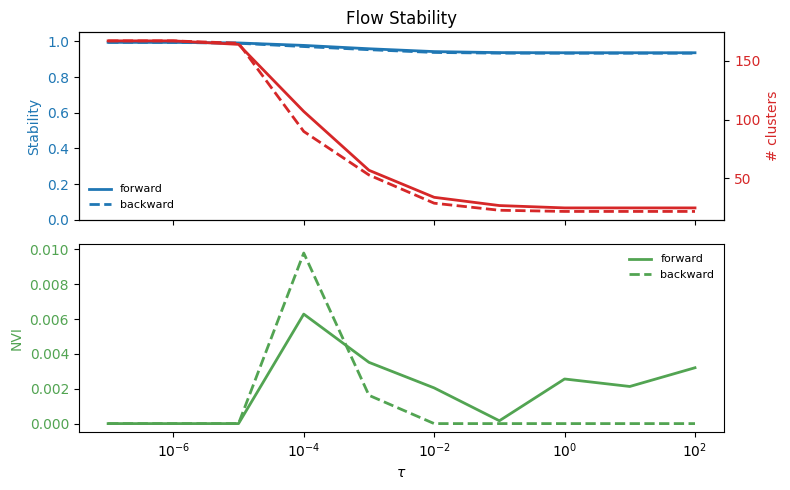

In [27]:
fig = plot_flow_stability(f_results, b_results, scales)
plt.show()

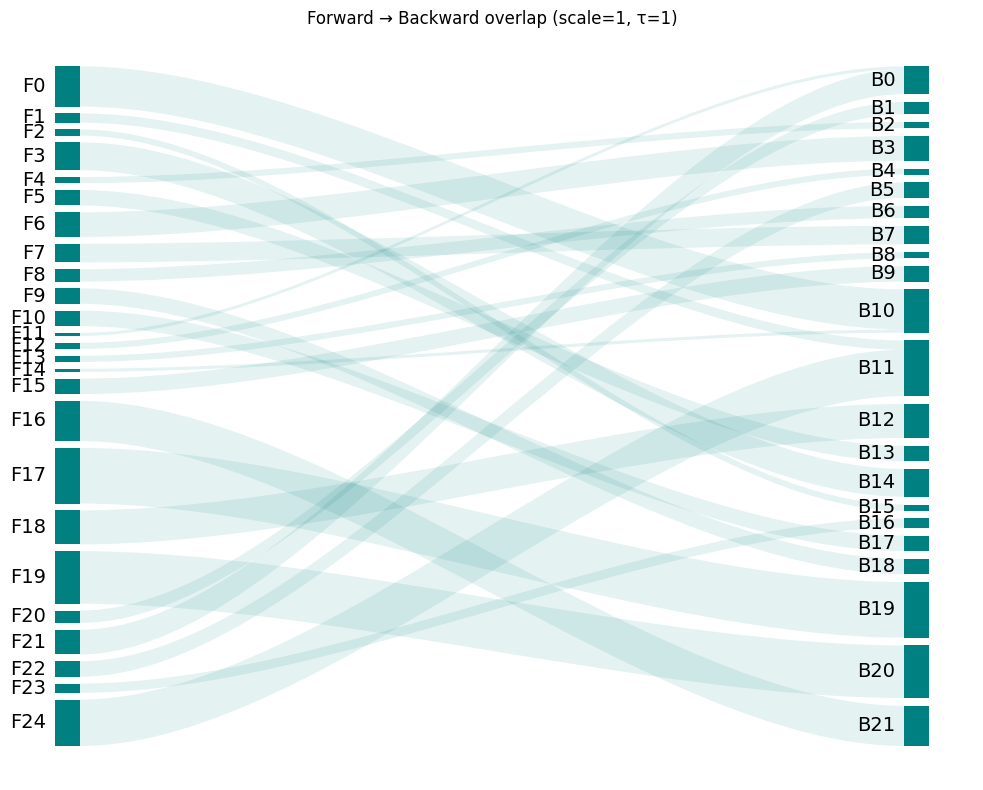

In [28]:
plot_forward_backward_sankey(f_results, b_results, scale=scales[-3])